# SIGMA - Logistic Regression Training (Enhanced)

Notebook pembanding untuk SIGMA.
Mencakup:
- Data Understanding
- Correlation Matrix
- Feature Scaling
- Logistic Regression
- Cross Validation
- Overfitting Check
- Recall Berisiko
- Confusion Matrix
- Analisis Koefisien


In [18]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [19]:

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "dataset" / "SIGMA_dataset_300.csv"

df = pd.read_csv(DATASET_PATH)

df.head()


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif,risiko_keterlambatan
0,1,20,2,44,4,8,Berisiko
1,2,18,1,50,4,7,Berisiko
2,3,58,3,60,4,6,Berisiko
3,4,35,0,51,0,3,Berisiko
4,5,41,0,40,0,8,Berisiko


In [20]:

print(df.shape)
df.info()
df.describe()


(300, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            300 non-null    int64 
 1   progres_skripsi               300 non-null    int64 
 2   frekuensi_bimbingan_bulanan   300 non-null    int64 
 3   keterlambatan_milestone_hari  300 non-null    int64 
 4   streak_aktivitas_mingguan     300 non-null    int64 
 5   jumlah_revisi_aktif           300 non-null    int64 
 6   risiko_keterlambatan          300 non-null    object
dtypes: int64(6), object(1)
memory usage: 16.5+ KB


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,54.886667,2.270000,21.896667,3.556667,4.010000
std,86.746758,23.826164,1.401301,17.604898,2.065837,2.437836
min,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000
25%,75.750000,34.750000,1.000000,6.000000,2.000000,2.000000
50%,150.500000,53.500000,2.000000,16.000000,4.000000,4.000000
75%,225.250000,77.000000,3.000000,37.000000,5.000000,6.000000
max,300.000000,99.000000,5.000000,60.000000,7.000000,8.000000


In [21]:

df.isnull().sum()


id                              0
progres_skripsi                 0
frekuensi_bimbingan_bulanan     0
keterlambatan_milestone_hari    0
streak_aktivitas_mingguan       0
jumlah_revisi_aktif             0
risiko_keterlambatan            0
dtype: int64

In [22]:

df.duplicated().sum()


0

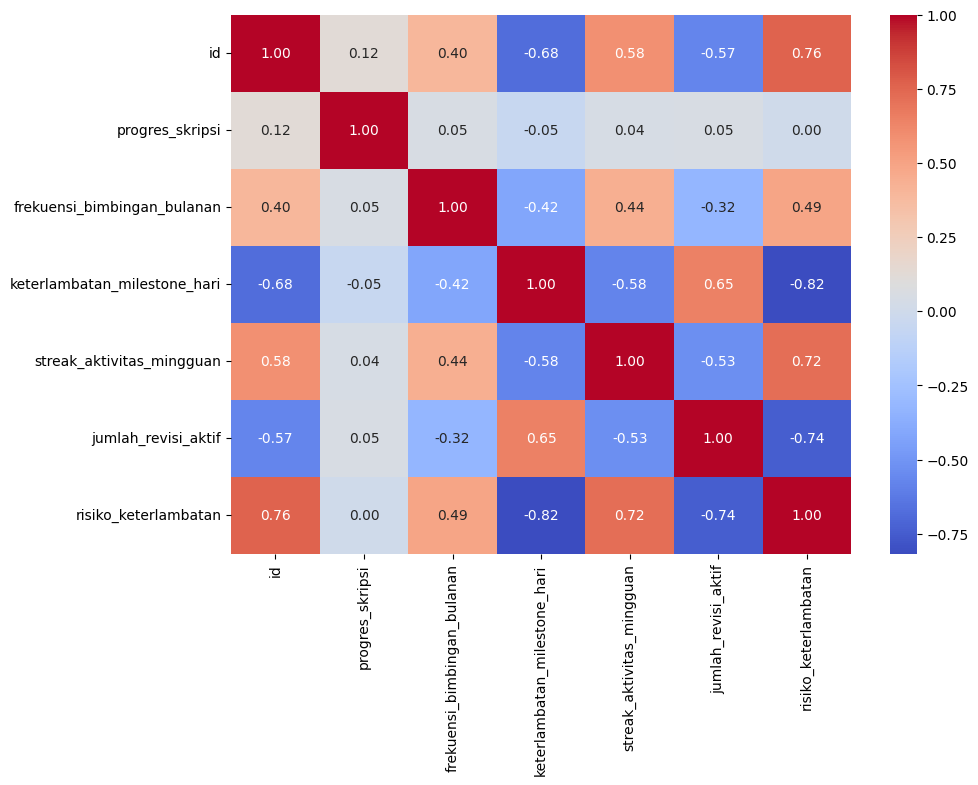

In [23]:

corr_df = df.copy()

temp_encoder = LabelEncoder()
corr_df['risiko_keterlambatan'] = temp_encoder.fit_transform(
    corr_df['risiko_keterlambatan']
)

plt.figure(figsize=(10,7))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


In [24]:

X = df.drop(columns=['id','risiko_keterlambatan'])
y = df['risiko_keterlambatan']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [25]:

X_train, X_test, y_train, y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [26]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)


LogisticRegression(max_iter=1000, random_state=42)

In [28]:

X_scaled = scaler.fit_transform(X)

cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y_encoded,
    cv=5,
    scoring='f1_macro'
)

print(cv_scores)
print(cv_scores.mean())


[0.95447942 0.86694856 0.86011069 0.96239676 0.93268048]
0.9153231794056842


In [29]:

train_pred = lr_model.predict(X_train_scaled)
test_pred = lr_model.predict(X_test_scaled)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy :', accuracy_score(y_test, test_pred))


Train Accuracy: 0.925
Test Accuracy : 0.8833333333333333


In [30]:

lr_pred = lr_model.predict(X_test_scaled)

print(classification_report(
    y_test,
    lr_pred,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

    Berisiko       0.93      0.97      0.95        29
  Cukup Aman       0.76      0.89      0.82        18
    On Track       1.00      0.69      0.82        13

    accuracy                           0.88        60
   macro avg       0.90      0.85      0.86        60
weighted avg       0.90      0.88      0.88        60



In [31]:

report = classification_report(
    y_test,
    lr_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

print('Recall Berisiko:', report['Berisiko']['recall'])


Recall Berisiko: 0.9655172413793104


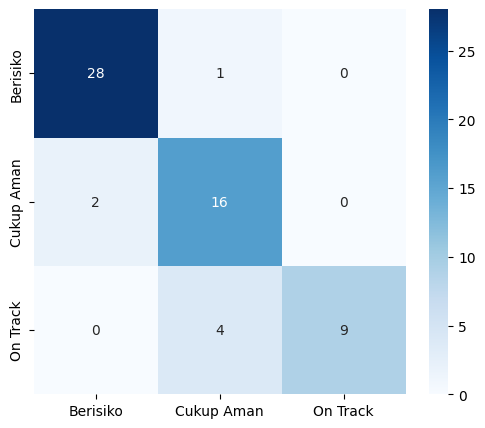

In [32]:

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.show()


In [33]:

coef_df = pd.DataFrame(
    lr_model.coef_.T,
    index=X.columns,
    columns=label_encoder.classes_
)

coef_df


,Berisiko,Cukup Aman,On Track
progres_skripsi,-0.104070,0.089467,0.014603
frekuensi_bimbingan_bulanan,-0.438538,-0.390513,0.829051
keterlambatan_milestone_hari,3.350613,0.146141,-3.496754
streak_aktivitas_mingguan,-1.283632,0.054086,1.229546
jumlah_revisi_aktif,1.416257,-0.165354,-1.250903


In [34]:

joblib.dump(lr_model,'sigma_logistic_regression.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(label_encoder,'label_encoder.pkl')


['label_encoder.pkl']